In [1]:
import os
os.getcwd()

'/Projects/Bhavesh_project/cct_notebooks'

In [18]:
import os, zipfile, urllib.request

URL = "https://lila.science/public/lila-md-results/caltech-camera-traps_mdv5a.0.0_results.filtered_rde_0.150_0.850_10_0.300.json.zip"
ZIP_FILE = "cct_md_results.zip"

if not os.path.exists("cct_md.json"):
    print("Downloading and extracting...")
    urllib.request.urlretrieve(URL, ZIP_FILE)
    with zipfile.ZipFile(ZIP_FILE, 'r') as z:
        z.extractall()
    os.remove(ZIP_FILE)
    print("Done.")

In [ ]:
import json

# Load the data
with open("cct_md.json", "r") as f:
    data = json.load(f)

# The MegaDetector format is a dictionary with keys: 'info', 'images', 'categories'
# Let's print the 'info' and the first 3 images
print("--- Dataset Info ---")
print(json.dumps(data.get('info', {}), indent=2))

print("\n--- First 3 Image Entries ---")
first_few_images = data.get('images', [])[:3]
print(json.dumps(first_few_images, indent=2))


In [20]:
import os

# 1. Define the URL
metadata_url = "https://storage.googleapis.com/public-datasets-lila/caltechcameratraps/labels/caltech_camera_traps.json.zip"

# 2. Download the file using !wget (fastest for public cloud links)
!wget {metadata_url}


--2026-04-29 17:47:22--  https://storage.googleapis.com/public-datasets-lila/caltechcameratraps/labels/caltech_camera_traps.json.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.209.27, 142.251.141.187, 142.251.38.155, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.209.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9013179 (8.6M) [application/zip]
Saving to: ‘caltech_camera_traps.json.zip.1’

caltech_camera_trap 100%[===================>]   8.59M  --.-KB/s    in 0.1s    

2026-04-29 17:47:22 (83.7 MB/s) - ‘caltech_camera_traps.json.zip.1’ saved [9013179/9013179]



In [7]:
# 3. Unzip the file
!unzip caltech_camera_traps.json.zip

Archive:  caltech_camera_traps.json.zip
  inflating: caltech_images_20210113.json  


In [2]:
import json
with open('caltech_images_20210113.json') as f:  # adjust filename if different
    data = json.load(f)

print(json.dumps(data['images'][0], indent=2))
print(json.dumps(data['images'][1], indent=2))

{
  "seq_num_frames": 1,
  "date_captured": "2013-10-04 13:31:53",
  "seq_id": "6f2160eb-5567-11e8-990e-dca9047ef277",
  "height": 1494,
  "width": 2048,
  "location": "26",
  "rights_holder": "Erin Boydston",
  "file_name": "5968c0f9-23d2-11e8-a6a3-ec086b02610b.jpg",
  "id": "5968c0f9-23d2-11e8-a6a3-ec086b02610b",
  "frame_num": 1
}
{
  "seq_num_frames": 1,
  "date_captured": "2013-11-04 18:37:07",
  "seq_id": "6f27ed66-5567-11e8-9e92-dca9047ef277",
  "height": 1494,
  "width": 2048,
  "location": "26",
  "rights_holder": "Erin Boydston",
  "file_name": "5a0b016f-23d2-11e8-a6a3-ec086b02610b.jpg",
  "id": "5a0b016f-23d2-11e8-a6a3-ec086b02610b",
  "frame_num": 1
}


In [8]:
import os
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.cloud import storage
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────────────────────
METADATA_PATH = "caltech_images_20210113.json"
CCT_DATA_DIR  = "../../../media/Data-10T-1/Bhavesh-project/CCT_data"
GCS_BUCKET    = "public-datasets-lila"
GCS_PREFIX    = "caltech-unzipped/cct_images/"

# ── Config ───────────────────────────────────────────────────────────────────
NUM_WORKERS       = 8      
EMPTY_KEYWORDS    = {"empty"}

In [ ]:
os.makedirs(CCT_DATA_DIR, exist_ok=True)
print(f"Target directory: {os.path.abspath(CCT_DATA_DIR)}")

In [19]:
from collections import Counter

with open(METADATA_PATH) as f:
    data = json.load(f)

cat_id_to_name = {c["id"]: c["name"].lower().strip() for c in data["categories"]}

category_counts = Counter(
    cat_id_to_name.get(a["category_id"], "unknown")
    for a in data["annotations"]
)

total = sum(category_counts.values())
for species, count in category_counts.most_common():
    print(f"{species:<20} {count:>6}  ({100 * count / total:.1f}%)")
print(f"\nTotal annotations: {total}")

empty                125745  (51.3%)
opossum               16698  (6.8%)
coyote                16601  (6.8%)
rabbit                12519  (5.1%)
deer                  12196  (5.0%)
raccoon               11390  (4.6%)
bird                  10003  (4.1%)
bobcat                 8098  (3.3%)
cat                    5297  (2.2%)
car                    4717  (1.9%)
dog                    4512  (1.8%)
squirrel               4450  (1.8%)
rodent                 4279  (1.7%)
cow                    3626  (1.5%)
fox                    2574  (1.1%)
skunk                  1898  (0.8%)
lizard                  309  (0.1%)
mountain_lion           145  (0.1%)
badger                   50  (0.0%)
insect                    6  (0.0%)
bat                       3  (0.0%)
pig                       2  (0.0%)

Total annotations: 245118


In [9]:
print("Loading metadata...")
with open(METADATA_PATH) as f:
    data = json.load(f)

# Map category IDs to names for easy lookup
cat_id_to_name = {c["id"]: c["name"].lower().strip() for c in data["categories"]}

# Filter annotations: image_id → species (excluding empties)
img_id_to_species = {}
for a in data["annotations"]:
    name = cat_id_to_name.get(a["category_id"], "")
    if name not in EMPTY_KEYWORDS:
        img_id_to_species[a["image_id"]] = name

cct_species_set = sorted(set(img_id_to_species.values()))

print(f"Non-empty annotated images found: {len(img_id_to_species)}")
print(f"Species list: {cct_species_set}")
print(f"Number of species: {len(cct_species_set)}")

Loading metadata...
Non-empty annotated images found: 117355
Species list: ['badger', 'bat', 'bird', 'bobcat', 'car', 'cat', 'cow', 'coyote', 'deer', 'dog', 'fox', 'insect', 'lizard', 'mountain_lion', 'opossum', 'pig', 'rabbit', 'raccoon', 'rodent', 'skunk', 'squirrel']
Number of species: 21


In [11]:
data['images']['location']

'26'

In [23]:
download_tasks = []   # list of (gcs_blob_path, local_path, image_id)
img_id_to_meta = {img["id"]: img for img in data["images"]}

for img_id, species in img_id_to_species.items():
    img = img_id_to_meta.get(img_id)
    if img is None or img.get("corrupt", False):
        continue

    file_name  = img["file_name"] 
    local_name = file_name.replace("/", "_") # Flatten path to filename
    local_path = os.path.join(CCT_DATA_DIR, local_name)

    # Skip if already downloaded
    if os.path.exists(local_path):
        continue

    gcs_blob = GCS_PREFIX + file_name
    download_tasks.append((gcs_blob, local_path, img_id))

print(f"Total target images        : {len(img_id_to_species)}")
print(f"Images already downloaded  : {len(img_id_to_species) - len(download_tasks)}")
print(f"Images remaining to fetch  : {len(download_tasks)}")

Total target images        : 117355
Images already downloaded  : 1
Images remaining to fetch  : 117354


In [22]:
# Initialize GCS Client
client = storage.Client.create_anonymous_client()
bucket = client.bucket(GCS_BUCKET)

def download_one(task):
    gcs_blob_path, local_path, img_id = task
    try:
        blob = bucket.blob(gcs_blob_path)
        blob.download_to_filename(local_path)
        return (img_id, True, None)
    except Exception as e:
        return (img_id, False, str(e))
    
test_tasks = download_tasks[:1]

if test_tasks:
    img_id, ok, err = download_one(test_tasks[0])
    if ok:
        print(f"Success: image {img_id}")
    else:
        print(f"Failed: image {img_id} — {err}")
else:
    print("No tasks available.")

Success: image 58d61304-23d2-11e8-a6a3-ec086b02610b


In [24]:
failed = []

# Start ThreadPool
if len(download_tasks) > 0:
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
        futures = {pool.submit(download_one, t): t for t in download_tasks}
        
        with tqdm(total=len(download_tasks), desc="Downloading Images") as pbar:
            for future in as_completed(futures):
                img_id, ok, err = future.result()
                if not ok:
                    failed.append((img_id, err))
                pbar.update(1)

    print(f"\n Process Finished")
    print(f"Success : {len(download_tasks) - len(failed)}")
    print(f"Failed  : {len(failed)}")
    
    if failed:
        print("\nFirst 10 failures:")
        for fid, ferr in failed[:10]:
            print(f"ID {fid}: {ferr}")
else:
    print("No new images to download.")

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)




 Process Finished
Success : 117354
Failed  : 0


In [25]:
print(len(os.listdir(CCT_DATA_DIR)))

117355


In [1]:
import os
import json
import h5py
import numpy as np
from pathlib import Path
from PIL import Image
import torch
from transformers import AutoImageProcessor, AutoModel
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────────────────────
METADATA_JSON    = "caltech_images_20210113.json"
MD_JSON          = "cct_md.json"
CCT_DATA_DIR     = "../../../media/Data-10T-1/Bhavesh-project/CCT_data"
OUTPUT_H5        = "../embeddings/cct_dinov2l_embeddings.h5"

# ── Config ───────────────────────────────────────────────────────────────────
DINOV2_MODEL     = "facebook/dinov2-large"   # ViT-L/14, 1024-dim CLS
PADDING_FRACTION = 0.10                      # 10% relative padding each side
BATCH_SIZE       = 32                        # images per GPU batch
EMPTY_LABELS     = {"empty"}
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


/usr/local/lib/python3.8/dist-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/usr/local/lib/python3.8/dist-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://g

In [ ]:
def md_to_key(md_file: str) -> str:
    return md_file.replace("\\", "/")

def key_to_local(key: str) -> str:
    return key.replace("/", "_")

def get_location(file_name: str) -> str:
    parts = Path(file_name).parts
    return parts[1] if len(parts) > 2 else "unknown"

def crop_with_padding(image: Image.Image, bbox: list, pad: float = PADDING_FRACTION) -> Image.Image:
    img_w, img_h = image.size
    x_min, y_min, box_w, box_h = bbox[0]*img_w, bbox[1]*img_h, bbox[2]*img_w, bbox[3]*img_h

    pad_x, pad_y = pad * box_w, pad * box_h
    x0, y0 = max(0, x_min - pad_x), max(0, y_min - pad_y)
    x1, y1 = min(img_w, x_min + box_w + pad_x), min(img_h, y_min + box_h + pad_y)

    return image.crop((x0, y0, x1, y1))

In [ ]:
def build_md_lookup(md_json_path):
    print(f"Loading MegaDetector JSON...")
    with open(md_json_path) as f:
        md = json.load(f)
    lookup = {}
    for img in md["images"]:
        key = md_to_key(img["file"])
        animal_dets = [d for d in img.get("detections", []) if d["category"] == "1"]
        if animal_dets:
            lookup[key] = max(animal_dets, key=lambda d: d["conf"])
    return lookup

def build_meta_lookup(metadata_json_path):
    print(f"Loading metadata...")
    with open(metadata_json_path) as f:
        data = json.load(f)
    cat_id_to_name = {c["id"]: c["name"].lower().strip() for c in data["categories"]}
    id_to_filename = {img["id"]: img["file_name"] for img in data["images"]}
    
    lookup = {}
    for ann in data["annotations"]:
        name = cat_id_to_name.get(ann["category_id"], "")
        if name not in EMPTY_LABELS:
            file_name = id_to_filename.get(ann["image_id"])
            if file_name: lookup[file_name] = name
    return lookup

md_lookup = build_md_lookup(MD_JSON)
meta_lookup = build_meta_lookup(METADATA_JSON)

In [ ]:
cct_dir = Path(CCT_DATA_DIR)
local_files = list(cct_dir.glob("*.JPG")) + list(cct_dir.glob("*.jpg"))
work = []
skipped_no_species, skipped_no_det = 0, 0

# Faster lookup using local name as key
meta_local_map = {key_to_local(k): k for k in meta_lookup.keys()}

for local_path in tqdm(local_files, desc="Building work list"):
    canonical_key = meta_local_map.get(local_path.name)
    
    if canonical_key is None:
        skipped_no_species += 1
        continue

    species = meta_lookup[canonical_key]
    det = md_lookup.get(canonical_key)
    
    if det is None:
        skipped_no_det += 1
        continue

    work.append((local_path, canonical_key, species, det))

print(f"\nTo embed: {len(work)} | No species: {skipped_no_species} | No MD detection: {skipped_no_det}")

In [ ]:
print(f"Loading {DINOV2_MODEL}...")
processor = AutoImageProcessor.from_pretrained(DINOV2_MODEL)
model = AutoModel.from_pretrained(DINOV2_MODEL).to(DEVICE).eval()

already_done = set()
if os.path.exists(OUTPUT_H5):
    with h5py.File(OUTPUT_H5, "r") as hf:
        if "file_name" in hf:
            already_done = set(n.decode() for n in hf["file_name"][:])
    print(f"Resuming: {len(already_done)} embeddings already exist.")

# Initialize datasets if they don't exist
with h5py.File(OUTPUT_H5, "a") as hf:
    for ds_name, shape, dtype in [
        ("embeddings", (0, 1024), "float32"),
        ("file_name", (0,), h5py.string_dtype()),
        ("species", (0,), h5py.string_dtype()),
        ("location", (0,), h5py.string_dtype())
    ]:
        if ds_name not in hf:
            max_shape = (None, 1024) if ds_name == "embeddings" else (None,)
            chunks = (64, 1024) if ds_name == "embeddings" else True
            hf.create_dataset(ds_name, shape=shape, maxshape=max_shape, dtype=dtype, chunks=chunks)

In [ ]:
batch_crops = []
batch_metadata = []

def flush_batch(hf, crops, meta):
    inputs = processor(images=crops, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().float().numpy()

    n = len(hf["embeddings"])
    m = len(crops)
    for key in ["embeddings", "file_name", "species", "location"]:
        hf[key].resize(n + m, axis=0)

    hf["embeddings"][n:n+m] = cls_embeddings
    hf["file_name"][n:n+m]  = [d["file_name"].encode() for d in meta]
    hf["species"][n:n+m]    = [d["species"].encode() for d in meta]
    hf["location"][n:n+m]   = [d["location"].encode() for d in meta]
    crops.clear(); meta.clear()

with h5py.File(OUTPUT_H5, "a") as hf:
    for local_path, canonical_key, species, det in tqdm(work, desc="Embedding"):
        if canonical_key in already_done: continue

        try:
            image = Image.open(local_path).convert("RGB")
            crop = crop_with_padding(image, det["bbox"])
            batch_crops.append(crop)
            batch_metadata.append({
                "file_name": canonical_key,
                "species": species,
                "location": get_location(canonical_key),
            })
        except Exception as e:
            print(f"Error processing {local_path}: {e}")
            continue

        if len(batch_crops) >= BATCH_SIZE:
            flush_batch(hf, batch_crops, batch_metadata)

    if batch_crops:
        flush_batch(hf, batch_crops, batch_metadata)

print("Processing complete.")

In [4]:
with h5py.File(OUTPUT_H5, "r") as hf:
    print(f"H5 Summary:")
    print(f"Total Records: {len(hf['embeddings'])}")
    print(f"Embedding Shape: {hf['embeddings'].shape}")
    print(f"First 3 species: {[s.decode() for s in hf['species'][:3]]}")

H5 Summary:
Total Records: 10
Embedding Shape: (10, 1024)
First 3 species: ['squirrel', 'bird', 'squirrel']


In [6]:
import h5py

# Open the file in read mode
with h5py.File(OUTPUT_H5, "r") as hf:
    if "location" in hf:
        # Read all locations, decode from bytes to utf-8
        locations = [loc.decode('utf-8') for loc in hf["date_captured"][:]]
        
        # Get unique values and sort them
        unique_locations = sorted(list(set(locations)))
        
        print(f"Found {len(unique_locations)} unique locations:")
        for loc in unique_locations:
            print(f" - {loc}")
    else:
        print("Dataset 'location' not found in the H5 file.")

Found 10 unique locations:
 - 2011-05-24 09:14:09
 - 2011-07-23 21:03:21
 - 2011-07-24 03:30:23
 - 2011-07-30 17:03:55
 - 2011-11-29 10:08:17
 - 2012-03-04 19:23:12
 - 2012-04-29 12:01:02
 - 2012-06-03 22:19:17
 - 2014-01-27 07:57:00
 - 2014-04-03 15:19:19


In [ ]:
import h5py
import numpy as np
import faiss
from collections import Counter
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# 1. Load data from H5
with h5py.File(OUTPUT_H5, "r") as hf:
    embeddings = hf["embeddings"][:]
    file_names = [f.decode() for f in hf["file_name"][:]]
    species    = [s.decode() for s in hf["species"][:]]
    locations  = [l.decode() for l in hf["location"][:]]

# 2. Identify indices for Gallery and Query based on location > 28
# Note: We convert location to int for comparison
gallery_mask = []
query_mask = []

for loc in locations:
    try:
        is_query = loc in {'B05', 'B06', 'B07', 'B08', 'B09'}
        query_mask.append(is_query)
        gallery_mask.append(not is_query)
    except ValueError:
        # Handle non-numeric locations if they exist
        query_mask.append(False)
        gallery_mask.append(True)

# 3. Create initial sets
gal_vecs_raw = embeddings[gallery_mask]
gal_labels_raw = np.array(species)[gallery_mask]

qry_vecs_raw = embeddings[query_mask]
qry_labels_raw = np.array(species)[query_mask]

# 4. Intersection of species
common_species = sorted(list(set(gal_labels_raw) & set(qry_labels_raw)))

def filter_to_common(vecs, labels, common):
    mask = np.isin(labels, common)
    return vecs[mask], labels[mask]

gal_vecs, gal_labels = filter_to_common(gal_vecs_raw, gal_labels_raw, common_species)
qry_vecs, qry_labels = filter_to_common(qry_vecs_raw, qry_labels_raw, common_species)

print(f"Species in intersection: {len(common_species)}")
print(f"Gallery size: {len(gal_labels)} | Query size: {len(qry_labels)}")

In [ ]:
# 1. Normalize embeddings for Cosine Similarity
def normalize_vecs(vecs):
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    return vecs / (norms + 1e-10)

gal_vecs_norm = normalize_vecs(gal_vecs)
qry_vecs_norm = normalize_vecs(qry_vecs)

# 2. Map species strings to IDs
cls2idx = {s: i for i, s in enumerate(common_species)}
idx2cls = {i: s for s, i in cls2idx.items()}
gal_idx = np.array([cls2idx[l] for l in gal_labels])
qry_idx = np.array([cls2idx[l] for l in qry_labels])

# 3. Setup FAISS Index
dim = gal_vecs_norm.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(gal_vecs_norm.astype('float32'))

# 4. Search (K=3 for top-3 accuracy and voting)
K = 3
distances, indices = index.search(qry_vecs_norm.astype('float32'), K)

In [ ]:
# 1. Predictions calculation
top1_preds = []
top3_correct = 0

for i, neighbors in enumerate(indices):
    neighbor_labels = gal_idx[neighbors]
    
    # Top-1: Majority vote among K neighbors
    vote = Counter(neighbor_labels).most_common(1)[0][0]
    top1_preds.append(vote)
    
    # Top-3: Success if the true label is among the 3 nearest neighbors
    if qry_idx[i] in neighbor_labels:
        top3_correct += 1

top1_preds = np.array(top1_preds)

# 2. Basic Metrics
top1_acc = (top1_preds == qry_idx).mean() * 100
top3_acc = (top3_correct / len(qry_idx)) * 100
macro_f1 = f1_score(qry_idx, top1_preds, average='macro', zero_division=0)

print(f"Search Results:")
print(f"{'Top-1 Accuracy:':<20} {top1_acc:.2f}%")
print(f"{'Top-3 Accuracy:':<20} {top3_acc:.2f}%")
print(f"{'Macro F1-Score:':<20} {macro_f1:.4f}")

# 3. Per-Class Accuracy and Size
print(f"\n{'Species':<25} | {'Size (Query)':<12} | {'Accuracy':<10}")
print("-" * 55)

# Calculate confusion matrix for per-class accuracy
cm = confusion_matrix(qry_idx, top1_preds, labels=range(len(common_species)))
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-10)
query_class_counts = Counter(qry_idx)

for i, species_name in enumerate(common_species):
    size = query_class_counts[i]
    acc = per_class_acc[i] * 100
    print(f"{species_name:<25} | {size:<12} | {acc:.2f}%")

# 4. Confusion Matrix (Simplified view for large label sets)
if len(common_species) < 15:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=common_species, yticklabels=common_species)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
else:
    print("\n(Confusion Matrix is too large for clear display; use per-class stats above)")

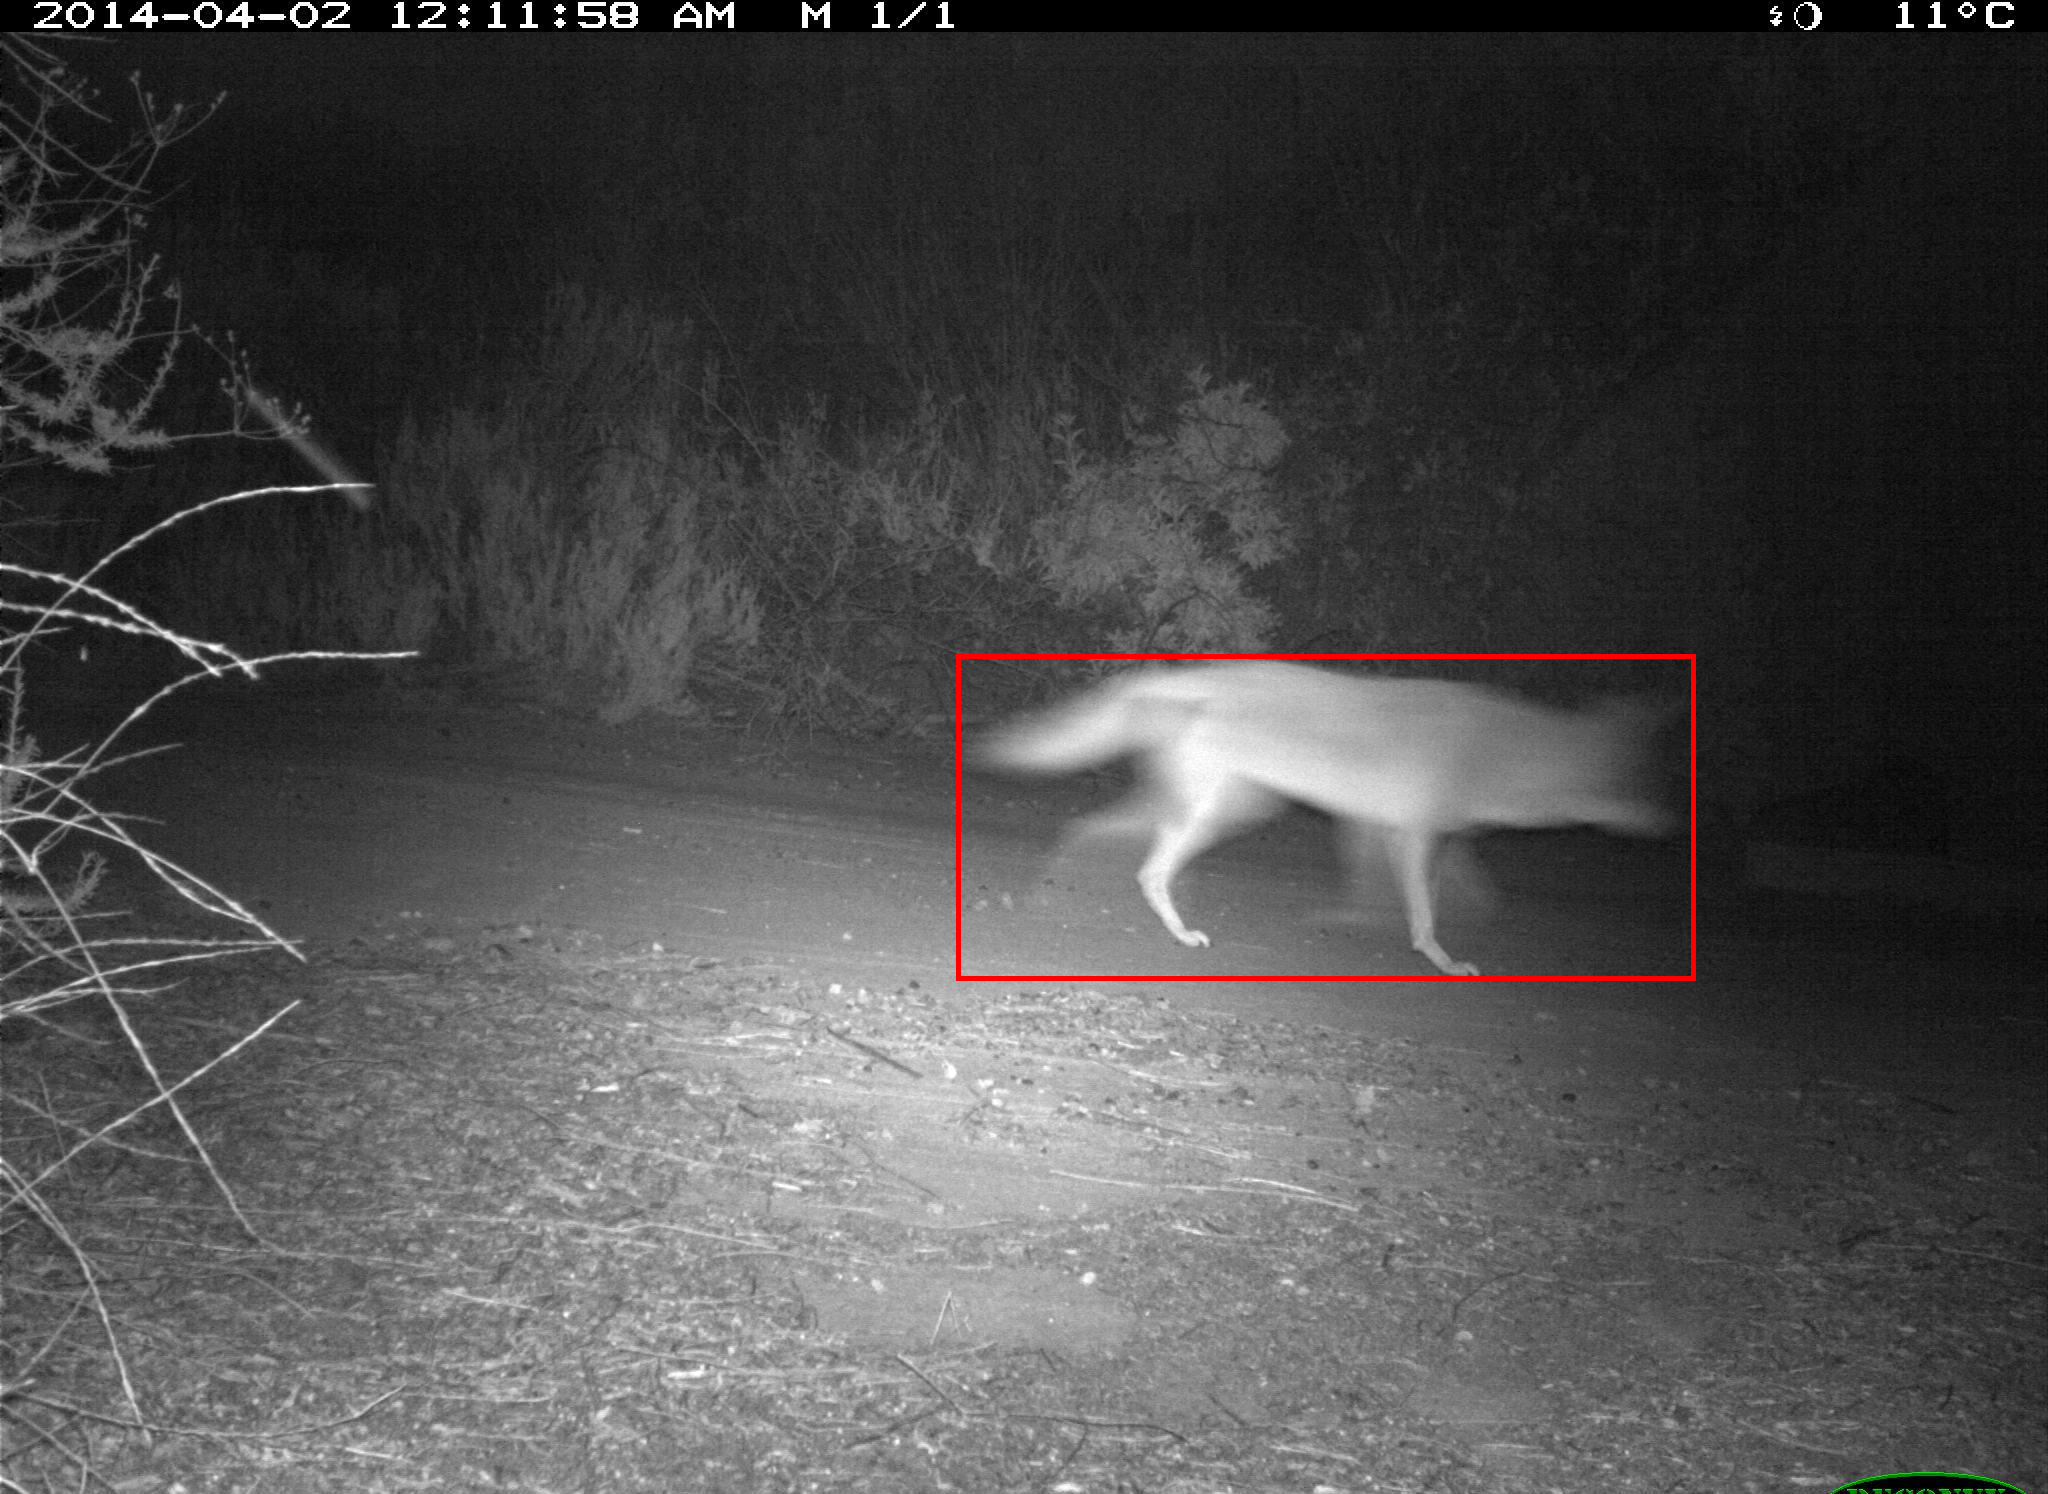

In [13]:
import PIL.Image as Image
import PIL.ImageDraw as ImageDraw


def draw_md_bbox(img_path, md_output):
    """
    Correctly maps MegaDetector normalized output to image coordinates.
    md_output expected as list/dict: [ymin, xmin, height, width]
    """
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w, h = img.size

    # MegaDetector Index Mapping:
    # 0: ymin, 1: xmin, 2: height, 3: width
    #x_min, y_min, box_w, box_h = bbox[0]*img_w, bbox[1]*img_h, bbox[2]*img_w, bbox[3]*img_h
    ymin_norm = float(md_output[1])
    xmin_norm = float(md_output[0])
    h_norm = float(md_output[3])
    w_norm = float(md_output[2])

    # Calculate pixel coordinates
    left = xmin_norm * w
    top = ymin_norm * h
    right = (xmin_norm + w_norm) * w
    bottom = (ymin_norm + h_norm) * h

    # Draw a thick box to confirm alignment
    draw.rectangle([left, top, right, bottom], outline="red", width=5)
    
    return img

# Example usage with your data:
bbox_data = [0.467, 0.438, 0.361, 0.218]
result_img = draw_md_bbox("../../../media/Data-10T-1/Bhavesh-project/CCT_data/585a65e6-23d2-11e8-a6a3-ec086b02610b.jpg", bbox_data)
result_img.show()

#verify_md_bbox("../../../media/Data-10T-1/Bhavesh-project/CCT_data/586ae112-23d2-11e8-a6a3-ec086b02610b.jpg", md_output)